In [2]:
!pip install transformers datasets pillow

In [3]:
!git clone https://github.com/watermelon-3012/sroie-ocr-ie.git

Cloning into 'sroie-ocr-ie'...
remote: Enumerating objects: 5239, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 5239 (delta 4), reused 3 (delta 0), pack-reused 5230 (from 4)
Receiving objects: 100% (5239/5239), 641.29 MiB | 22.27 MiB/s, done.
Resolving deltas: 100% (1534/1534), done.
Updating files: 100% (3617/3617), done.


In [4]:
%cd sroie-ocr-ie

/content/sroie-ocr-ie


In [5]:
import torch
torch.cuda.is_available()

True

In [6]:
import os
import json
import torch
from PIL import Image
from pathlib import Path
from datasets import Dataset

from transformers import (
    LayoutLMv3Processor,
    LayoutLMv3ForTokenClassification,
    TrainingArguments,
    Trainer
)

In [7]:
# Dataset
BASE_PATH = Path("/content/sroie-ocr-ie")

TRAIN_BOX = BASE_PATH / "data/train/box"
TRAIN_IMG = BASE_PATH / "data/train/img"
TRAIN_ENT = BASE_PATH / "data/train/entities"

In [8]:
# Label

label_list = [
    "O",
    "B-COMPANY","I-COMPANY",
    "B-ADDRESS","I-ADDRESS",
    "B-DATE","I-DATE",
    "B-TOTAL","I-TOTAL"
]

label2id = {l:i for i,l in enumerate(label_list)}
id2label = {i:l for l,i in label2id.items()}

In [9]:
print(label2id)

{'O': 0, 'B-COMPANY': 1, 'I-COMPANY': 2, 'B-ADDRESS': 3, 'I-ADDRESS': 4, 'B-DATE': 5, 'I-DATE': 6, 'B-TOTAL': 7, 'I-TOTAL': 8}


In [10]:
print(id2label)

{0: 'O', 1: 'B-COMPANY', 2: 'I-COMPANY', 3: 'B-ADDRESS', 4: 'I-ADDRESS', 5: 'B-DATE', 6: 'I-DATE', 7: 'B-TOTAL', 8: 'I-TOTAL'}


In [11]:
import re

def normalize(text):
    return re.sub(r"[^a-z0-9]", "", text.lower())
# def normalize(text):
#     return re.sub(r"[^a-z0-9/.]", "", text.lower())

In [12]:
x = normalize("BOOK TA .K (TAMAN DAYA) SDN BHD")
print(x)

booktaktamandayasdnbhd


In [13]:
def split_lines_to_words(lines, boxes):
    """
    Hàm này tách các dòng OCR thành các từ đơn lẻ
    và nhân bản bounding box tương ứng cho mỗi từ.
    """
    word_tokens = []
    word_boxes = []

    for line, box in zip(lines, boxes):
        words_in_line = str(line).split() # Cắt dòng thành các từ bằng khoảng trắng
        for w in words_in_line:
            word_tokens.append(w)
            word_boxes.append(box) # Tạm thời dùng chung box của cả dòng cho từ

    return word_tokens, word_boxes

Cái load OCR này hay bị lỗi vì original train dataset text-box dùng file .txt mà chạy paddle ocr xong thì mình lại có file .json

Nên là anh bảo nó làm cho anh 2 cái hàm load_ocr khác nhau để đỡ lỗi nhá :))

In [14]:
import json

def load_ocr(path):

    words = []
    boxes = []

    if path.suffix == ".json":

        with open(path, encoding="utf-8") as f:
            data = json.load(f)

        for item in data:
            words.append(item["text"])

            xs = [p[0] for p in item["bbox"]]
            ys = [p[1] for p in item["bbox"]]

            x1, x2 = min(xs), max(xs)
            y1, y2 = min(ys), max(ys)

            boxes.append([x1, y1, x2, y2])

    else:  # txt

        with open(path, encoding="utf-8") as f:
            for line in f:

                parts = line.strip().split(",")

                coords = list(map(float, parts[:8]))
                text = ",".join(parts[8:])

                xs = coords[0::2]
                ys = coords[1::2]

                x1, x2 = min(xs), max(xs)
                y1, y2 = min(ys), max(ys)

                words.append(text)
                boxes.append([x1, y1, x2, y2])

    return words, boxes

In [15]:
def normalize_boxes(boxes, width, height):

    normalized = []

    for box in boxes:

        x1 = int(1000 * box[0] / width)
        y1 = int(1000 * box[1] / height)
        x2 = int(1000 * box[2] / width)
        y2 = int(1000 * box[3] / height)

        normalized.append([x1,y1,x2,y2])

    return normalized

In [16]:
def load_entities(path):

    with open(path, encoding="utf-8") as f:
        return json.load(f)

In [17]:
# Create BIO label

def create_labels(tokens, entities):
    labels = ["O"] * len(tokens)

    entity_map = {
        "company": "COMPANY",
        "address": "ADDRESS",
        "date": "DATE",
        "total": "TOTAL"
    }
    normalized_doc_tokens = [normalize(t) for t in tokens]
    # all_value = []
    for key, tag in entity_map.items():
        value = entities.get(key, "")

        if not value:
            continue

        value_tokens = [normalize(t) for t in value.split()]
        #all_value.append(value_tokens)
        n_val = len(value_tokens)

        if n_val == 0:
            continue

# Slicing window
        for i in range(len(normalized_doc_tokens) - n_val + 1):


            window = normalized_doc_tokens[i : i + n_val]

            if window == value_tokens:

                if all(label == "O" for label in labels[i : i + n_val]):

                    labels[i] = f"B-{tag}" # Từ đầu tiên là B-
                    for j in range(1, n_val):
                        labels[i + j] = f"I-{tag}" # Các từ tiếp theo là I-
                    break

    return labels

In [18]:
# # Build dataset

# samples = []

# for file in os.listdir(TRAIN_BOX):

#     if not file.endswith(".txt"):
#         continue

#     rid = file.replace(".txt","")

#     img_path = TRAIN_IMG / f"{rid}.jpg"
#     box_path = TRAIN_BOX / file
#     ent_path = TRAIN_ENT / f"{rid}.json"

#     image = Image.open(img_path).convert("RGB")
#     width, height = image.size

#     words, boxes = load_ocr(box_path)
#     boxes = normalize_boxes(boxes, width, height)

#     entities = load_entities(ent_path)

#     labels, all_value, normal_tok = create_labels(words, entities)

#     samples.append({
#         "image": image,
#         "tokens": words,
#         "boxes": boxes,
#         "labels": labels,
#         'value':all_value,
#         'normal':normal_tok
#     })

# print("Samples:", len(samples))

In [19]:
samples = []

for file in os.listdir(TRAIN_BOX):
    if not file.endswith(".txt"):
        continue

    rid = file.replace(".txt","")
    img_path = TRAIN_IMG / f"{rid}.jpg"
    box_path = TRAIN_BOX / file
    ent_path = TRAIN_ENT / f"{rid}.json"

    image = Image.open(img_path).convert("RGB")
    width, height = image.size

    # 1. Load dòng và hộp từ file text
    words, boxes = load_ocr(box_path)

    # -----------------------------------------------------
    # 2. BƯỚC MỚI: Tách dòng thành từ, nhân bản bounding box
    words, boxes = split_lines_to_words(words, boxes)
    # -----------------------------------------------------

    # 3. Chuẩn hóa hộp
    boxes = normalize_boxes(boxes, width, height)

    entities = load_entities(ent_path)

    # 4. Truyền vào hàm tạo nhãn. Lúc này 'words' đã là từ đơn
    labels= create_labels(words, entities)

    samples.append({
        "image": image,
        "tokens": words,
        "boxes": boxes,
        "labels": labels
    })
print("Samples:", len(samples))

Samples: 626


In [20]:
print(samples[0])

{'image': <PIL.Image.Image image mode=RGB size=782x2213 at 0x7A0F82D6C2F0>, 'tokens': ['CHILI', "'", 'S', "CHILI'S", 'GRILL', '&', 'BAR', 'CKLCC', 'T.A.S', 'LEISURE', 'SDN', 'BHD', '(256864-P)', 'TEL:', '03-2164', '1400', 'GST', 'ID:', '001042104320', 'TAX', 'RECEIPT', 'GST', 'ID:', '001042104320', '4', 'CHILIS3', '23', 'ANIS', 'CHK', '1080323', 'GST4', '30', 'DEC', '17', '18:40:57', 'TBL64', '/', '1', 'EAT', 'IN', '1', 'PINEAPPLE', 'JUICE', '12.95', 'S', '1', 'TOSTADA', 'CHIPS', '16.95', 'S', '1', 'CHP_BWL', 'CK', '29.95', 'S', '1', 'MARG', 'CK', '27.95', 'S', 'SUBTOTAL', '87.80', '10%', 'SRV', 'CHG', '8.78', 'GST', '@6%', '5.81', 'TOTAL:', '102.39', '0.01', 'TOTAL', '102.40', 'YOUR', 'OPINION', 'MATTERS', 'WE', 'INVITE', 'YOU', 'TO', 'COMPLETE', 'OUR', 'GUEST', 'EXPERIENCE', 'SURVEY', 'YOU', 'COULD', 'WIN', 'RM500', 'CASH', 'OR', "CHILI'S", 'VOUCHER', 'FOR', 'RM1,000', 'A', 'WINNER', 'EVERY', 'MONTH', 'VISIT', 'WWW.GO-CHILIS.COM', 'YOUR', 'SURVEY', 'CODE:', '5013', 'PLS', 'ENTER', 'W

In [21]:
print(samples[0].get('tokens'))


['CHILI', "'", 'S', "CHILI'S", 'GRILL', '&', 'BAR', 'CKLCC', 'T.A.S', 'LEISURE', 'SDN', 'BHD', '(256864-P)', 'TEL:', '03-2164', '1400', 'GST', 'ID:', '001042104320', 'TAX', 'RECEIPT', 'GST', 'ID:', '001042104320', '4', 'CHILIS3', '23', 'ANIS', 'CHK', '1080323', 'GST4', '30', 'DEC', '17', '18:40:57', 'TBL64', '/', '1', 'EAT', 'IN', '1', 'PINEAPPLE', 'JUICE', '12.95', 'S', '1', 'TOSTADA', 'CHIPS', '16.95', 'S', '1', 'CHP_BWL', 'CK', '29.95', 'S', '1', 'MARG', 'CK', '27.95', 'S', 'SUBTOTAL', '87.80', '10%', 'SRV', 'CHG', '8.78', 'GST', '@6%', '5.81', 'TOTAL:', '102.39', '0.01', 'TOTAL', '102.40', 'YOUR', 'OPINION', 'MATTERS', 'WE', 'INVITE', 'YOU', 'TO', 'COMPLETE', 'OUR', 'GUEST', 'EXPERIENCE', 'SURVEY', 'YOU', 'COULD', 'WIN', 'RM500', 'CASH', 'OR', "CHILI'S", 'VOUCHER', 'FOR', 'RM1,000', 'A', 'WINNER', 'EVERY', 'MONTH', 'VISIT', 'WWW.GO-CHILIS.COM', 'YOUR', 'SURVEY', 'CODE:', '5013', 'PLS', 'ENTER', 'WITHIN', 'THE', 'NEXT', '4', 'DAYS', 'MUST', 'BE', '18', 'OR', 'ABOVE,', 'VOID', 'WHERE

In [22]:
# Convert to HuggingFace Dataset
dataset = Dataset.from_list(samples)

In [23]:
# Load processor
processor = LayoutLMv3Processor.from_pretrained(
    "microsoft/layoutlmv3-base",
    apply_ocr=False
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

In [24]:
print(dataset.column_names)

['image', 'tokens', 'boxes', 'labels']


In [25]:
label2id = {
    "O": 0,

    "B-COMPANY": 1,
    "I-COMPANY": 2,

    "B-DATE": 3,
    "I-DATE": 4,

    "B-TOTAL": 5,
    "I-TOTAL": 6,

    "B-ADDRESS": 7,
    "I-ADDRESS": 8
}

id2label = {v:k for k,v in label2id.items()}

In [26]:
def convert_labels(example):
    example["labels"] = [label2id.get(label, 0) for label in example["labels"]]
    return example

dataset = dataset.map(convert_labels)

Map:   0%|          | 0/626 [00:00<?, ? examples/s]

In [27]:
def encode(example):
    encoding = processor(
        example["image"],
        text=example["tokens"],
        boxes=example["boxes"],
        word_labels=example["labels"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

    # remove extra dimension
    encoding["pixel_values"] = encoding["pixel_values"][0]

    return encoding

In [28]:
dataset = dataset.map(encode)
dataset.set_format(type="torch")

Map:   0%|          | 0/626 [00:00<?, ? examples/s]

In [29]:
print(dataset[0])

{'image': tensor([[[192, 193, 193,  ..., 216, 216, 218],
         [190, 190, 190,  ..., 214, 214, 215],
         [190, 190, 190,  ..., 213, 213, 213],
         ...,
         [186, 185, 186,  ..., 206, 203, 201],
         [189, 185, 182,  ..., 206, 202, 200],
         [190, 183, 176,  ..., 206, 202, 199]],

        [[188, 189, 189,  ..., 216, 216, 218],
         [186, 186, 186,  ..., 214, 214, 215],
         [186, 186, 186,  ..., 213, 213, 213],
         ...,
         [188, 187, 188,  ..., 208, 205, 203],
         [191, 187, 184,  ..., 208, 204, 202],
         [192, 185, 178,  ..., 208, 204, 201]],

        [[187, 188, 188,  ..., 214, 214, 216],
         [185, 185, 185,  ..., 212, 212, 213],
         [185, 185, 185,  ..., 211, 211, 211],
         ...,
         [187, 186, 187,  ..., 205, 202, 200],
         [190, 186, 183,  ..., 205, 201, 199],
         [191, 184, 177,  ..., 205, 201, 198]]], dtype=torch.uint8), 'tokens': ['CHILI', "'", 'S', "CHILI'S", 'GRILL', '&', 'BAR', 'CKLCC', 'T.A.

In [30]:
dataset.column_names

['image',
 'tokens',
 'boxes',
 'labels',
 'input_ids',
 'attention_mask',
 'bbox',
 'pixel_values']

In [31]:
# Remove unused columns in train data
dataset = dataset.remove_columns(["image", "tokens", "boxes"])

In [44]:
# Slit for train and val

splits = dataset.train_test_split(test_size=0.1, seed=42) # Added seed for reproducibility
train_dataset = splits['train']
validation_dataset = splits['test']

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")

Training dataset size: 563
Validation dataset size: 63


In [45]:
# Define model
model = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.weight                  | MISSING    | 
classifier.bias                    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
# Training Argument
training_args = TrainingArguments(

    output_dir="./layoutlmv3_sroie",

    learning_rate=3e-5,
    per_device_train_batch_size=2,
    num_train_epochs=10,

    logging_steps=50,
    save_strategy="epoch",
    eval_strategy="epoch", # Added evaluation strategy

    remove_unused_columns=False
)

In [47]:
# Train model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.097412,0.082921
2,0.068811,0.069527
3,0.063663,0.076531
4,0.038649,0.100555
5,0.036513,0.121458
6,0.032210,0.116544
7,0.023331,0.115443
8,0.016675,0.139899
9,0.016329,0.147789
10,0.019657,0.153486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2820, training_loss=0.05207068143108635, metrics={'train_runtime': 174.5612, 'train_samples_per_second': 32.252, 'train_steps_per_second': 16.155, 'total_flos': 1484124682659840.0, 'train_loss': 0.05207068143108635, 'epoch': 10.0})

In [ ]:
trainer.save_model("/content/sroie-ocr-ie/layoutlmv3_receipt_model")
processor.save_pretrained("/content/sroie-ocr-ie/layoutlmv3_receipt_model")

In [ ]:
# Load trained model
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification

processor = LayoutLMv3Processor.from_pretrained("layoutlmv3_receipt_model", apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained("layoutlmv3_receipt_model")

Loss curve saved to ./layoutlmv3_sroie/plots/layoutlmv3_loss_curve.png


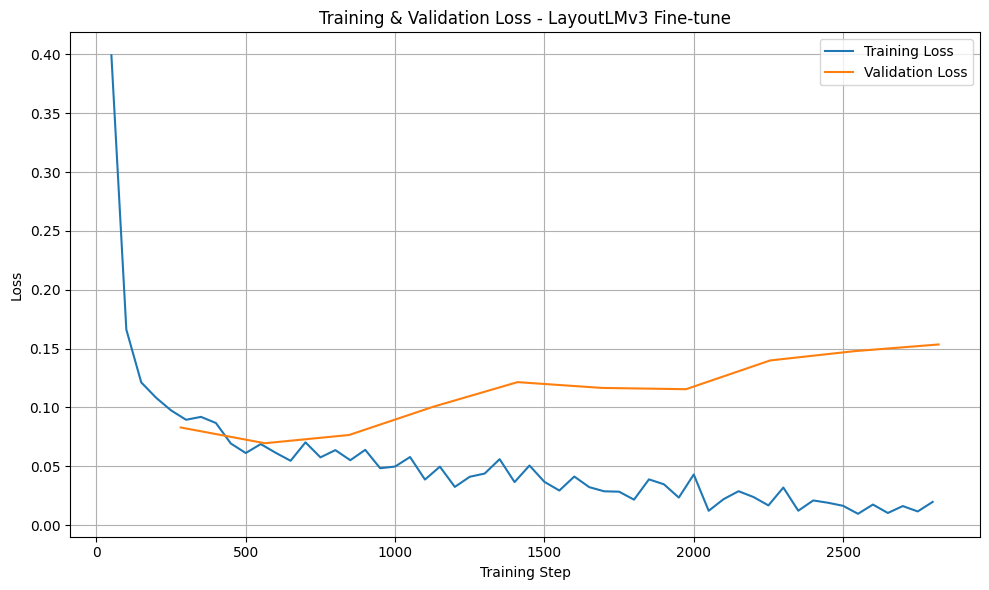

In [63]:
import matplotlib.pyplot as plt
import json
import os
import pandas as pd

# Dynamically find the latest checkpoint path
output_base_dir = "./layoutlmv3_sroie"
checkpoint_dirs = [d for d in os.listdir(output_base_dir) if d.startswith('checkpoint-')]
if checkpoint_dirs:
    # Sort to get the latest checkpoint (assuming numerical suffix)
    latest_checkpoint_dir = sorted(checkpoint_dirs, key=lambda x: int(x.split('-')[1]))[-1]
    final_log_path = os.path.join(output_base_dir, latest_checkpoint_dir, "trainer_state.json")
else:
    final_log_path = None # No checkpoint found

if final_log_path and os.path.exists(final_log_path):
    with open(final_log_path, 'r') as f:
        trainer_state = json.load(f)

    log_history = trainer_state.get('log_history', [])

    # Filter for training and evaluation loss entries
    train_losses = []
    eval_losses = []

    for entry in log_history:
        if 'loss' in entry: # Training loss
            train_losses.append({'epoch': entry['epoch'], 'loss': entry['loss'], 'step': entry['step']})
        if 'eval_loss' in entry: # Validation loss
            eval_losses.append({'epoch': entry['epoch'], 'eval_loss': entry['eval_loss'], 'step': entry['step']})

    # Convert to DataFrames for easier plotting
    train_df = pd.DataFrame(train_losses)
    eval_df = pd.DataFrame(eval_losses)

    plt.figure(figsize=(10, 6))

    if not train_df.empty:
        plt.plot(train_df['step'], train_df['loss'], label='Training Loss')
    if not eval_df.empty:
        plt.plot(eval_df['step'], eval_df['eval_loss'], label='Validation Loss')

    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss - LayoutLMv3 Fine-tune") # Changed title for LayoutLMv3
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save the plot
    save_dir = os.path.join(output_base_dir, "plots")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, "layoutlmv3_loss_curve.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Loss curve saved to {save_path}")

    plt.show()
else:
    print(f"Trainer state file not found at: {final_log_path}")

# TEST MODEL

In [49]:
import os
import json
import torch
from PIL import Image

# paths
OCR_PATH = "/content/sroie-ocr-ie/data_ocr/Text"
LABEL_PATH = "/content/sroie-ocr-ie/data/test/entities"
IMAGE_PATH = "/content/sroie-ocr-ie/data/test/img"

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
id2label = model.config.id2label

In [50]:
all_predicted_entities = {}
all_ground_truth_entities = {}

files = os.listdir(OCR_PATH)

for file in files:

    name = os.path.splitext(file)[0]

    ocr_file = Path(OCR_PATH) / file
    img_file = Path(IMAGE_PATH) / (name + ".jpg")
    gt_file = Path(LABEL_PATH) / (name + ".json")

    if not img_file.exists():
        continue

    image = Image.open(img_file).convert("RGB")
    width, height = image.size

    tokens, boxes = load_ocr(ocr_file)
    boxes = normalize_boxes(boxes, width, height)

    encoding = processor(
        image,
        tokens,
        boxes=boxes,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=512
    )

    word_ids = encoding.word_ids(batch_index=0)
    encoding_to_device = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding_to_device)

    logits = outputs.logits
    preds = torch.argmax(logits, dim=-1)[0].tolist()

    pred_labels = []
    previous_word_idx = None

    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        elif word_id != previous_word_idx:
            pred_labels.append(id2label[preds[idx]])
        previous_word_idx = word_id

    valid_tokens = tokens[:len(pred_labels)]

    pred_result = {}
    current_key = None

    for token, label in zip(valid_tokens, pred_labels):
        if label.startswith("B-"):
            if current_key and current_key in pred_result and isinstance(pred_result[current_key], list):
                # If a B-tag appears for the same key, and we have an ongoing entity,
                # it means the previous one finished. Join the words and store.
                pred_result[current_key].append(token)
            else:
                current_key = label[2:]
                pred_result[current_key] = [token] # Start a new list for the entity

        elif label.startswith("I-") and current_key == label[2:]:
            if current_key in pred_result and isinstance(pred_result[current_key], list):
                pred_result[current_key][-1] += " " + token # Append to the last item in the list

        else:
            current_key = None # Reset if 'O' or mismatching 'I-'

    # Convert lists to single strings for consistency, if an entity has multiple parts
    for key in pred_result:
        if isinstance(pred_result[key], list):
            pred_result[key] = " ".join(pred_result[key])

    # Load ground truth
    if gt_file.exists():
        with open(gt_file) as f:
            gt = json.load(f)
    else:
        gt = {}

    all_predicted_entities[name] = pred_result
    all_ground_truth_entities[name] = gt

print(f"Collected predictions and ground truths for {len(all_predicted_entities)} files.")

Collected predictions and ground truths for 347 files.


In [53]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 85.6 MB/s eta 0:00:00


In [55]:
import re
import Levenshtein

fields = ["company", "date", "address", "total"]

def normalize_text_for_eval(text):
    """Chuẩn hóa chuỗi: chuyển chữ thường, xóa khoảng trắng thừa để so sánh chính xác hơn."""
    if not isinstance(text, str): return str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text) # Gộp nhiều khoảng trắng thành 1
    return text.strip()


correct_matches = 0
total_predicted_entities = 0
total_ground_truth_entities = 0

field_correct = {f:0 for f in fields}
field_total = {f:0 for f in fields}

lev_scores = []

for file_id in all_ground_truth_entities:

    gt_entities = all_ground_truth_entities[file_id]
    pred_entities = all_predicted_entities.get(file_id, {})

    for f in fields:

        # Ground Truth value
        gt_val = gt_entities.get(f, "")
        normalized_gt = normalize_text_for_eval(gt_val)

        # Predicted value (keys in pred_entities are uppercase)
        pred_val = pred_entities.get(f.upper(), "")
        normalized_pred = normalize_text_for_eval(pred_val)

        if normalized_gt:
            field_total[f] += 1
            total_ground_truth_entities += 1

            if normalized_pred == normalized_gt:
                field_correct[f] += 1
                correct_matches += 1

            # Levenshtein similarity for non-empty ground truth fields
            if len(normalized_pred) > 0 or len(normalized_gt) > 0:
                # Avoid division by zero
                max_len = max(len(normalized_pred), len(normalized_gt))
                if max_len > 0:
                    sim = 1 - Levenshtein.distance(normalized_pred, normalized_gt) / max_len
                    lev_scores.append(sim)

        if normalized_pred:
            total_predicted_entities += 1 # Count predicted entities that are not empty


# Calculate overall metrics
precision = correct_matches / total_predicted_entities if total_predicted_entities > 0 else 0
recall = correct_matches / total_ground_truth_entities if total_ground_truth_entities > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("===== Field Accuracy ====")
for f in fields:
    acc = field_correct[f] / field_total[f] if field_total[f] > 0 else 0
    print(f"{f}: {acc:.3f}")

print("\n===== Entity Metrics ====")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

print("\n===== Levenshtein Similarity ====")
print(f"Average Similarity: {sum(lev_scores)/len(lev_scores):.3f}")


===== Field Accuracy ====
company: 0.285
date: 0.135
address: 0.037
total: 0.669

===== Entity Metrics ====
Precision: 0.403
Recall: 0.282
F1 Score: 0.331

===== Levenshtein Similarity ====
Average Similarity: 0.561


In [59]:
import pandas as pd

comparison_data = []

for file_id in all_ground_truth_entities:
    gt_entities = all_ground_truth_entities[file_id]
    pred_entities = all_predicted_entities.get(file_id, {})

    for f in fields:
        gt_val = gt_entities.get(f, "")
        pred_val = pred_entities.get(f.upper(), "") # Predicted keys are uppercase

        normalized_gt = normalize_text_for_eval(gt_val)
        normalized_pred = normalize_text_for_eval(pred_val)

        is_match = (normalized_pred == normalized_gt)

        comparison_data.append({
            "file_id": file_id,
            "field": f.upper(),
            "predicted_value": pred_val,
            "ground_truth_value": gt_val,
            "match": is_match
        })

comparison_df = pd.DataFrame(comparison_data)

print("Comparison DataFrame (first 5 rows):")
display(comparison_df.head())

Comparison DataFrame (first 5 rows):


,file_id,field,predicted_value,ground_truth_value,match
0,154,COMPANY,The Cut Steakhouse &Burgeis i.ot L1-4 Star Ave...,THE CUT STEAKHOUSE &BURGERS,False
1,154,DATE,,01-01-2017,False
2,154,ADDRESS,,LOT L1-4 STAR AVENUE MALL JALAN ZUHAL U5/179 S...,False
3,154,TOTAL,167.55,167.55,True
4,041,COMPANY,POPULAR BOOK CO.MSDN BHD,POPULAR BOOK CO. (M) SDN BHD,False
